In [22]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score,confusion_matrix

from sklearn.preprocessing import LabelEncoder

from tensorflow  import keras
from tensorflow.keras import layers , callbacks
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer

import re

In [23]:
df = pd.read_csv('text_emotion_assignment.csv')

In [24]:
df.head()

,text,emotion
0,i also hate how you feel the need to flee from...,hate
1,i cry i feel humiliated get angry dont talk to...,anger
2,i would sit on the toilet seat with my knees u...,enthusiasm
3,i pick my nails and skin and continue because ...,sadness
4,i got to eat plenty with family and feel more ...,relief


In [25]:
df['emotion'].value_counts()

emotion
hate          142
enthusiasm    130
relief        128
surprise      116
happiness     115
anger         114
sadness       107
fun           107
love          100
empty          89
neutral        89
Name: count, dtype: int64

In [26]:
text = df.text
y = df.emotion

In [27]:
text.shape

(1237,)

In [28]:
le = LabelEncoder()
y = le.fit_transform(y)

In [29]:
clean_text = [re.sub(r'[^\w\s]', '', x) for x in text]

In [30]:
clean_text

['i also hate how you feel the need to flee from your problems and refuse to speak to anyone who has wronged you',
 'i cry i feel humiliated get angry dont talk to people and i thing it s quite normal',
 'i would sit on the toilet seat with my knees up to my chest and move my lips with hers feeling excited about the exactness and precision by which she applied her make up',
 'i pick my nails and skin and continue because the pain is the only feeling i ever have other than apathy and melancholy',
 'i got to eat plenty with family and feel more than comfortable in my own skin',
 'i have found myself with less anxiety feeling less rushed and more relaxed this past two weeks',
 'i am excited about the things that i can do with the iphone but at the same time i know that many journalists would still not feel excited like me',
 'i can feel very uncomfortable',
 'i am starting to feel more calm and at ease but i think it will take a few weeks for me to feel completely settled here',
 'i dont 

In [31]:
X_train , X_test , y_train , y_test = train_test_split(clean_text , y , test_size=0.2,random_state=5)

In [32]:
tk = Tokenizer(num_words=1000)
tk.fit_on_texts(X_train)
X_train_seq = tk.texts_to_sequences(X_train)
X_test_seq = tk.texts_to_sequences(X_test)

In [33]:
max_len=20
X_train_seq_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_seq_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [34]:
model = keras.Sequential([
    layers.Embedding(input_dim =1000 , output_dim=16 ,input_length=20 , input_shape=(X_train_seq_pad.shape[1],)), #یاد گیرنده نیست
    layers.GRU(32, return_sequences=True , dropout=0.2),
    layers.GRU(16 , dropout=0.2),
    layers.Dense(16 , activation=layers.PReLU()),

    layers.Dense(11, activation='softmax')
])
adam = keras.optimizers.Adam(learning_rate=0.02)
model.compile(
    optimizer=adam,
    loss= 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 20, 16)            16000     
                                                                 
 gru_2 (GRU)                 (None, 20, 32)            4800      
                                                                 
 gru_3 (GRU)                 (None, 16)                2400      
                                                                 
 dense_2 (Dense)             (None, 16)                288       
                                                                 
 dense_3 (Dense)             (None, 11)                187       
                                                                 
Total params: 23,675
Trainable params: 23,675
Non-trainable params: 0
_________________________________________________________________


In [35]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.6)
history = model.fit(
X_train_seq_pad, y_train,
epochs = 100,
validation_split = 0.2,
batch_size = 16,
callbacks = [es, rlr]
)

Epoch 1/100
50/50 [==============================] - 2s 15ms/step - loss: 2.4012 - accuracy: 0.0923 - val_loss: 2.3898 - val_accuracy: 0.1263 - lr: 0.0200
Epoch 2/100
50/50 [==============================] - 0s 8ms/step - loss: 2.3885 - accuracy: 0.1113 - val_loss: 2.3471 - val_accuracy: 0.1414 - lr: 0.0200
Epoch 3/100
50/50 [==============================] - 0s 8ms/step - loss: 2.1092 - accuracy: 0.2212 - val_loss: 2.0160 - val_accuracy: 0.2626 - lr: 0.0200
Epoch 4/100
50/50 [==============================] - 0s 8ms/step - loss: 1.7699 - accuracy: 0.3148 - val_loss: 1.9430 - val_accuracy: 0.3384 - lr: 0.0200
Epoch 5/100
50/50 [==============================] - 0s 8ms/step - loss: 1.5611 - accuracy: 0.3919 - val_loss: 1.9400 - val_accuracy: 0.3737 - lr: 0.0200
Epoch 6/100
50/50 [==============================] - 0s 8ms/step - loss: 1.3104 - accuracy: 0.5145 - val_loss: 1.9151 - val_accuracy: 0.4242 - lr: 0.0200
Epoch 7/100
50/50 [==============================] - 0s 8ms/step - loss: 1.

In [36]:
y_pred = model.predict(X_test_seq_pad)
y_pred_argmax=np.argmax(y_pred , axis=1)
accuracy_score(y_test,y_pred_argmax)*100

8/8 [==============================] - 0s 2ms/step


58.46774193548387

<Axes: >

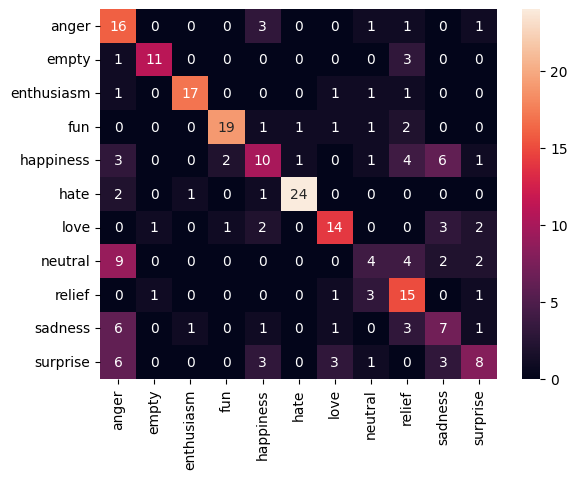

In [37]:
sns.heatmap(confusion_matrix(y_test, y_pred_argmax), annot=True, fmt = 'd', xticklabels=le.classes_, yticklabels=le.classes_)